In [1]:
import time
import json
import os
import sys
import math
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=False)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=100,adc_last_gap=100)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("../compiler/code/")
chip.compensation.initop("../chip_data/chip6_/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 64883
正在编译文件:  ../compiler/code/read_point3_from_col.txt
正在编译文件:  ../compiler/code/read_point3_from_row.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


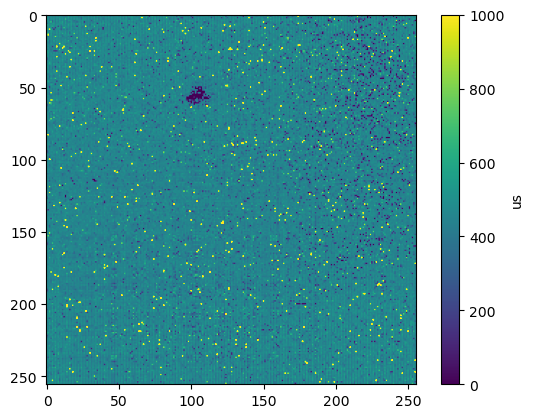

In [15]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

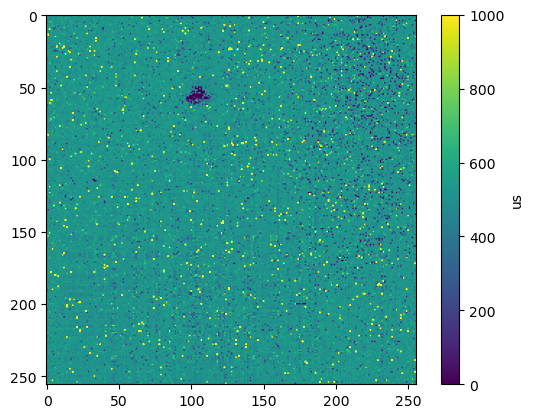

In [16]:
v,c,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

In [78]:
col = 10
select_num,total_num = 75,200


random_times = 100
real_res = np.zeros(random_times)
expected_res = np.zeros(random_times)
for i in range(random_times):
    rows_index = np.random.choice(total_num, select_num, replace=False)
    res = chip.read4(crossbar=np.ones((256,256)),row_index=rows_index,col_index=[col],read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
    print(np.max(res[0]))
    expected_res[i]=np.sum(c[rows_index,col])
    real_res[i]=res[1][col]

0.34813989684743796
0.3598132267220069
0.35721915341654714
0.35813470870082703
0.3567613757744072
0.3564180425428022
0.3569521164586321
0.3568376720480972
0.3535187841425825
0.3605380413220618
0.3567232276375622
0.3561891537217322
0.3539384136478774
0.3624073000274667
0.3598513748588519
0.36130100405896176
0.3518784142582476
0.3569521164586322
0.3564943388164922
0.3550828577532273
0.3545106357005524
0.3498184148686178
0.3650395214697714
0.36275063325907164
0.3545487838373974
0.3532517471846675
0.3577913754692221
0.3564943388164922
0.358859523300882
0.3562273018585772
0.3555787835322123
0.35458693197424235
0.36229285561693164
0.3598513748588519
0.35710470900601216
0.34436323129978336
0.35157322916348765
0.36286507766960663
0.3498565630054628
0.3544724875637074
0.35290841395306255
0.35302285836359754
0.35908841212195197
0.3547776726584673
0.35889767143772694
0.3596987823114719
0.358973967711417
0.36149174474318674
0.3500473036896878
0.35943174535355693
0.3562654499954222
0.35439619129001

拟合系数: -2.2454334107835963 59910.66861287807


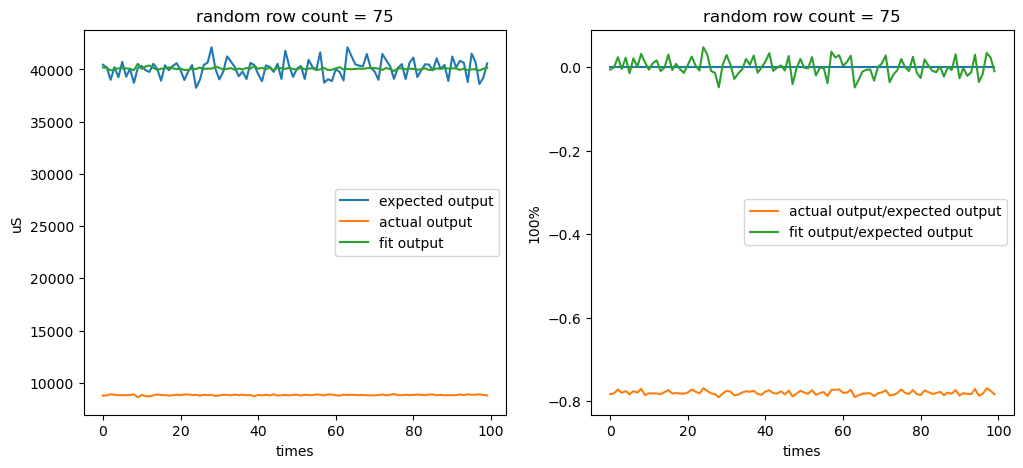

In [77]:
coefficients = np.polyfit(real_res, expected_res, 1)
print("拟合系数:", coefficients[0],coefficients[1])

# 拟合的线性函数
def linear_fit(x):
    return coefficients[0] * x + coefficients[1]

# 计算拟合的 y 值
y_fit = linear_fit(real_res)

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.title(f"random row count = {select_num}")
plt.plot(expected_res,label = "expected output")
plt.plot(real_res,label = "actual output")
plt.plot(y_fit,label = "fit output")
plt.ylabel("uS")
plt.xlabel("times")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.zeros(random_times))
plt.plot(real_res/expected_res-1,label = "actual output/expected output")
plt.plot(y_fit/expected_res-1,label = "fit output/expected output")
plt.ylabel("100%")
plt.xlabel("times")
plt.legend()
plt.title(f"random row count = {select_num}")
plt.show()